# CUTS-Plus Lightning 示例

本 Notebook 演示如何使用当前仓库的 Lightning 化实现来训练 CUTS-Plus，并导出与可视化最终因果图 `Graph.npy`。


In [1]:
# 环境与路径设置
import os, sys, time
import torch

# 可选：Tensor Cores 上更快的 float32 matmul
if torch.cuda.is_available():
    try:
        torch.set_float32_matmul_precision('medium')
    except Exception:
        pass

# 将项目根目录加入 sys.path（假设本 notebook 位于项目根目录）
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd()))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()}")


PROJECT_ROOT = /home/acme/yhy/STCausalPatch
CUDA available: True


In [2]:
# 导入依赖
from datetime import datetime
from omegaconf import OmegaConf
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger

# 项目内模块
from dataset.lorenz_datamodule import Lorenz96DataModule
from lightning_module import CUTSPlusLightning
from utils.misc import reproduc



In [3]:
# 加载配置与初始化 Logger/DataModule
config_path = "configs/lorenz_example.yaml"
opt = OmegaConf.load(config_path)

# 复现性
reproduc(**opt.reproduc)

# 任务名与日志
timestamp = datetime.now().strftime("_%Y%m%d_%H%M%S")
opt.task_name = (opt.task_name or "lorenz_cuts") + "_nb" + timestamp
log_dir = os.path.join(opt.dir_name, opt.task_name)
print(f"Logs will be saved to: {log_dir}")

# Logger（Lightning）
logger = TensorBoardLogger(save_dir=opt.dir_name, name=opt.task_name, default_hp_metric=False)

# DataModule
print("Setting up datamodule...")
datamodule = Lorenz96DataModule(
    data_config=opt.data,
    train_config=opt.sota.cuts_plus,
    reproduc_config=opt.reproduc,
)
datamodule.setup('fit')



Logs will be saved to: outputs/lorenz_cuts_nb_20251031_130058
Setting up datamodule...
Data shape: (1000, 128)
Resolved 'n_nodes: auto' to 128
Initial observable data ratio: 0.7004


In [4]:
# 初始化 LightningModule 与 Trainer，并开始训练
model = CUTSPlusLightning(
    train_config=opt.sota.cuts_plus,
    reproduc_config=opt.reproduc,
)

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
trainer = pl.Trainer(
    max_epochs=opt.sota.cuts_plus.total_epoch,
    logger=logger,
    accelerator=accelerator,
    devices=1,
    log_every_n_steps=10,
    check_val_every_n_epoch=opt.sota.cuts_plus.show_graph_every,
    enable_checkpointing=False,
    deterministic=opt.reproduc.deterministic,
)

trainer.fit(model, datamodule=datamodule)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Data shape: (1000, 128)
Initial observable data ratio: 0.7004



  | Name      | Type          | Params | Mode 
----------------------------------------------------
0 | model     | CUTS_Plus_Net | 31.0 K | train
1 | pred_loss | MSELoss       | 0      | train
----------------------------------------------------
31.0 K    Trainable params
0         Non-trainable params
31.0 K    Total params
0.124     Total estimated model params size (MB)
145       Modules in train mode
0         Modules in eval mode
/home/acme/yhy/STCausalPatch/.venv/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 63: 100%|██████████| 8/8 [00:00<00:00, 10.46it/s, v_num=0, train/pred_loss_step=0.552, train/graph_sparsity_loss_step=0.591, train/pred_loss_epoch=0.553, train/graph_sparsity_loss_epoch=0.591, metrics/auc=0.999]

`Trainer.fit` stopped: `max_epochs=64` reached.


Epoch 63: 100%|██████████| 8/8 [00:02<00:00,  3.55it/s, v_num=0, train/pred_loss_step=0.552, train/graph_sparsity_loss_step=0.591, train/pred_loss_epoch=0.553, train/graph_sparsity_loss_epoch=0.591, metrics/auc=0.999]


Reading Graph.npy from: outputs/lorenz_cuts_nb_20251031_130058/version_0
Graph shape: (128, 128)


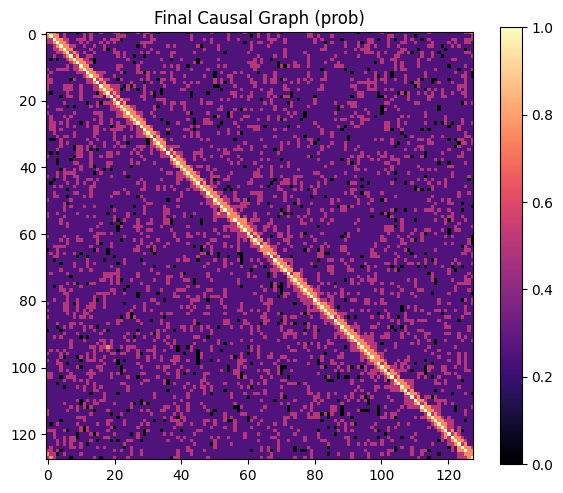

In [6]:
# 读取导出的 Graph.npy 并做简单可视化
import numpy as np
import matplotlib.pyplot as plt

# lightning_module.on_fit_end 会将 Graph.npy 保存到 logger 目录
log_dir_guess = None
if hasattr(logger, 'log_dir') and logger.log_dir is not None:
    log_dir_guess = logger.log_dir
else:
    log_dir_guess = os.path.join(logger.save_dir, logger.name, f"version_{logger.version}")

print(f"Reading Graph.npy from: {log_dir_guess}")
graph_path = os.path.join(log_dir_guess, 'Graph.npy')

if os.path.exists(graph_path):
    Graph = np.load(graph_path)
    print("Graph shape:", Graph.shape)
    graph = (Graph - np.min(Graph)) / (np.max(Graph) - np.min(Graph))

    plt.figure(figsize=(6, 5))
    plt.imshow(graph, cmap='magma', vmin=0, vmax=1)
    plt.title('Final Causal Graph (prob)')
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("Graph.npy not found. Check that training finished and saving succeeded.")



## 运行 Lorenz patches 版本实验

下面的单元将使用 `configs/lorenz_patches_example.yaml`，训练并可视化结果，同时展示 ground truth（true_cm）。


In [7]:
# 载入 patches 配置并训练
opt2 = OmegaConf.load("configs/lorenz_patches_example.yaml")

# 复现性
reproduc(**opt2.reproduc)

# Logger / DataModule / Model / Trainer
logger2 = TensorBoardLogger(save_dir=opt2.dir_name, name=opt2.task_name + "_nb", default_hp_metric=False)

datamodule2 = Lorenz96DataModule(
    data_config=opt2.data,
    train_config=opt2.sota.cuts_plus,
    reproduc_config=opt2.reproduc,
)
datamodule2.setup('fit')

model2 = CUTSPlusLightning(
    train_config=opt2.sota.cuts_plus,
    reproduc_config=opt2.reproduc,
)

accelerator2 = 'gpu' if torch.cuda.is_available() else 'cpu'
trainer2 = pl.Trainer(
    max_epochs=opt2.sota.cuts_plus.total_epoch,
    logger=logger2,
    accelerator=accelerator2,
    devices=1,
    log_every_n_steps=10,
    check_val_every_n_epoch=opt2.sota.cuts_plus.show_graph_every,
    enable_checkpointing=False,
    deterministic=opt2.reproduc.deterministic,
)

trainer2.fit(model2, datamodule=datamodule2)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data shape: (1000, 128)
Resolved 'n_nodes: auto' to 128
Initial observable data ratio: 0.7004


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Data shape: (1000, 128)
Initial observable data ratio: 0.7004



  | Name      | Type          | Params | Mode 
----------------------------------------------------
0 | model     | CUTS_Plus_Net | 31.0 K | train
1 | pred_loss | MSELoss       | 0      | train
----------------------------------------------------
31.0 K    Trainable params
0         Non-trainable params
31.0 K    Total params
0.124     Total estimated model params size (MB)
145       Modules in train mode
0         Modules in eval mode
/home/acme/yhy/STCausalPatch/.venv/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 63: 100%|██████████| 8/8 [00:00<00:00, 11.58it/s, v_num=0, train/pred_loss_step=0.110, train/graph_sparsity_loss_step=0.591, train/pred_loss_epoch=0.109, train/graph_sparsity_loss_epoch=0.590, metrics/auc=1.000]

`Trainer.fit` stopped: `max_epochs=64` reached.


Epoch 63: 100%|██████████| 8/8 [00:02<00:00,  3.46it/s, v_num=0, train/pred_loss_step=0.110, train/graph_sparsity_loss_step=0.591, train/pred_loss_epoch=0.109, train/graph_sparsity_loss_epoch=0.590, metrics/auc=1.000]


Reading Graph.npy from: outputs/lorenz_patches_cuts_nb/version_0
Graph shape: (128, 128)


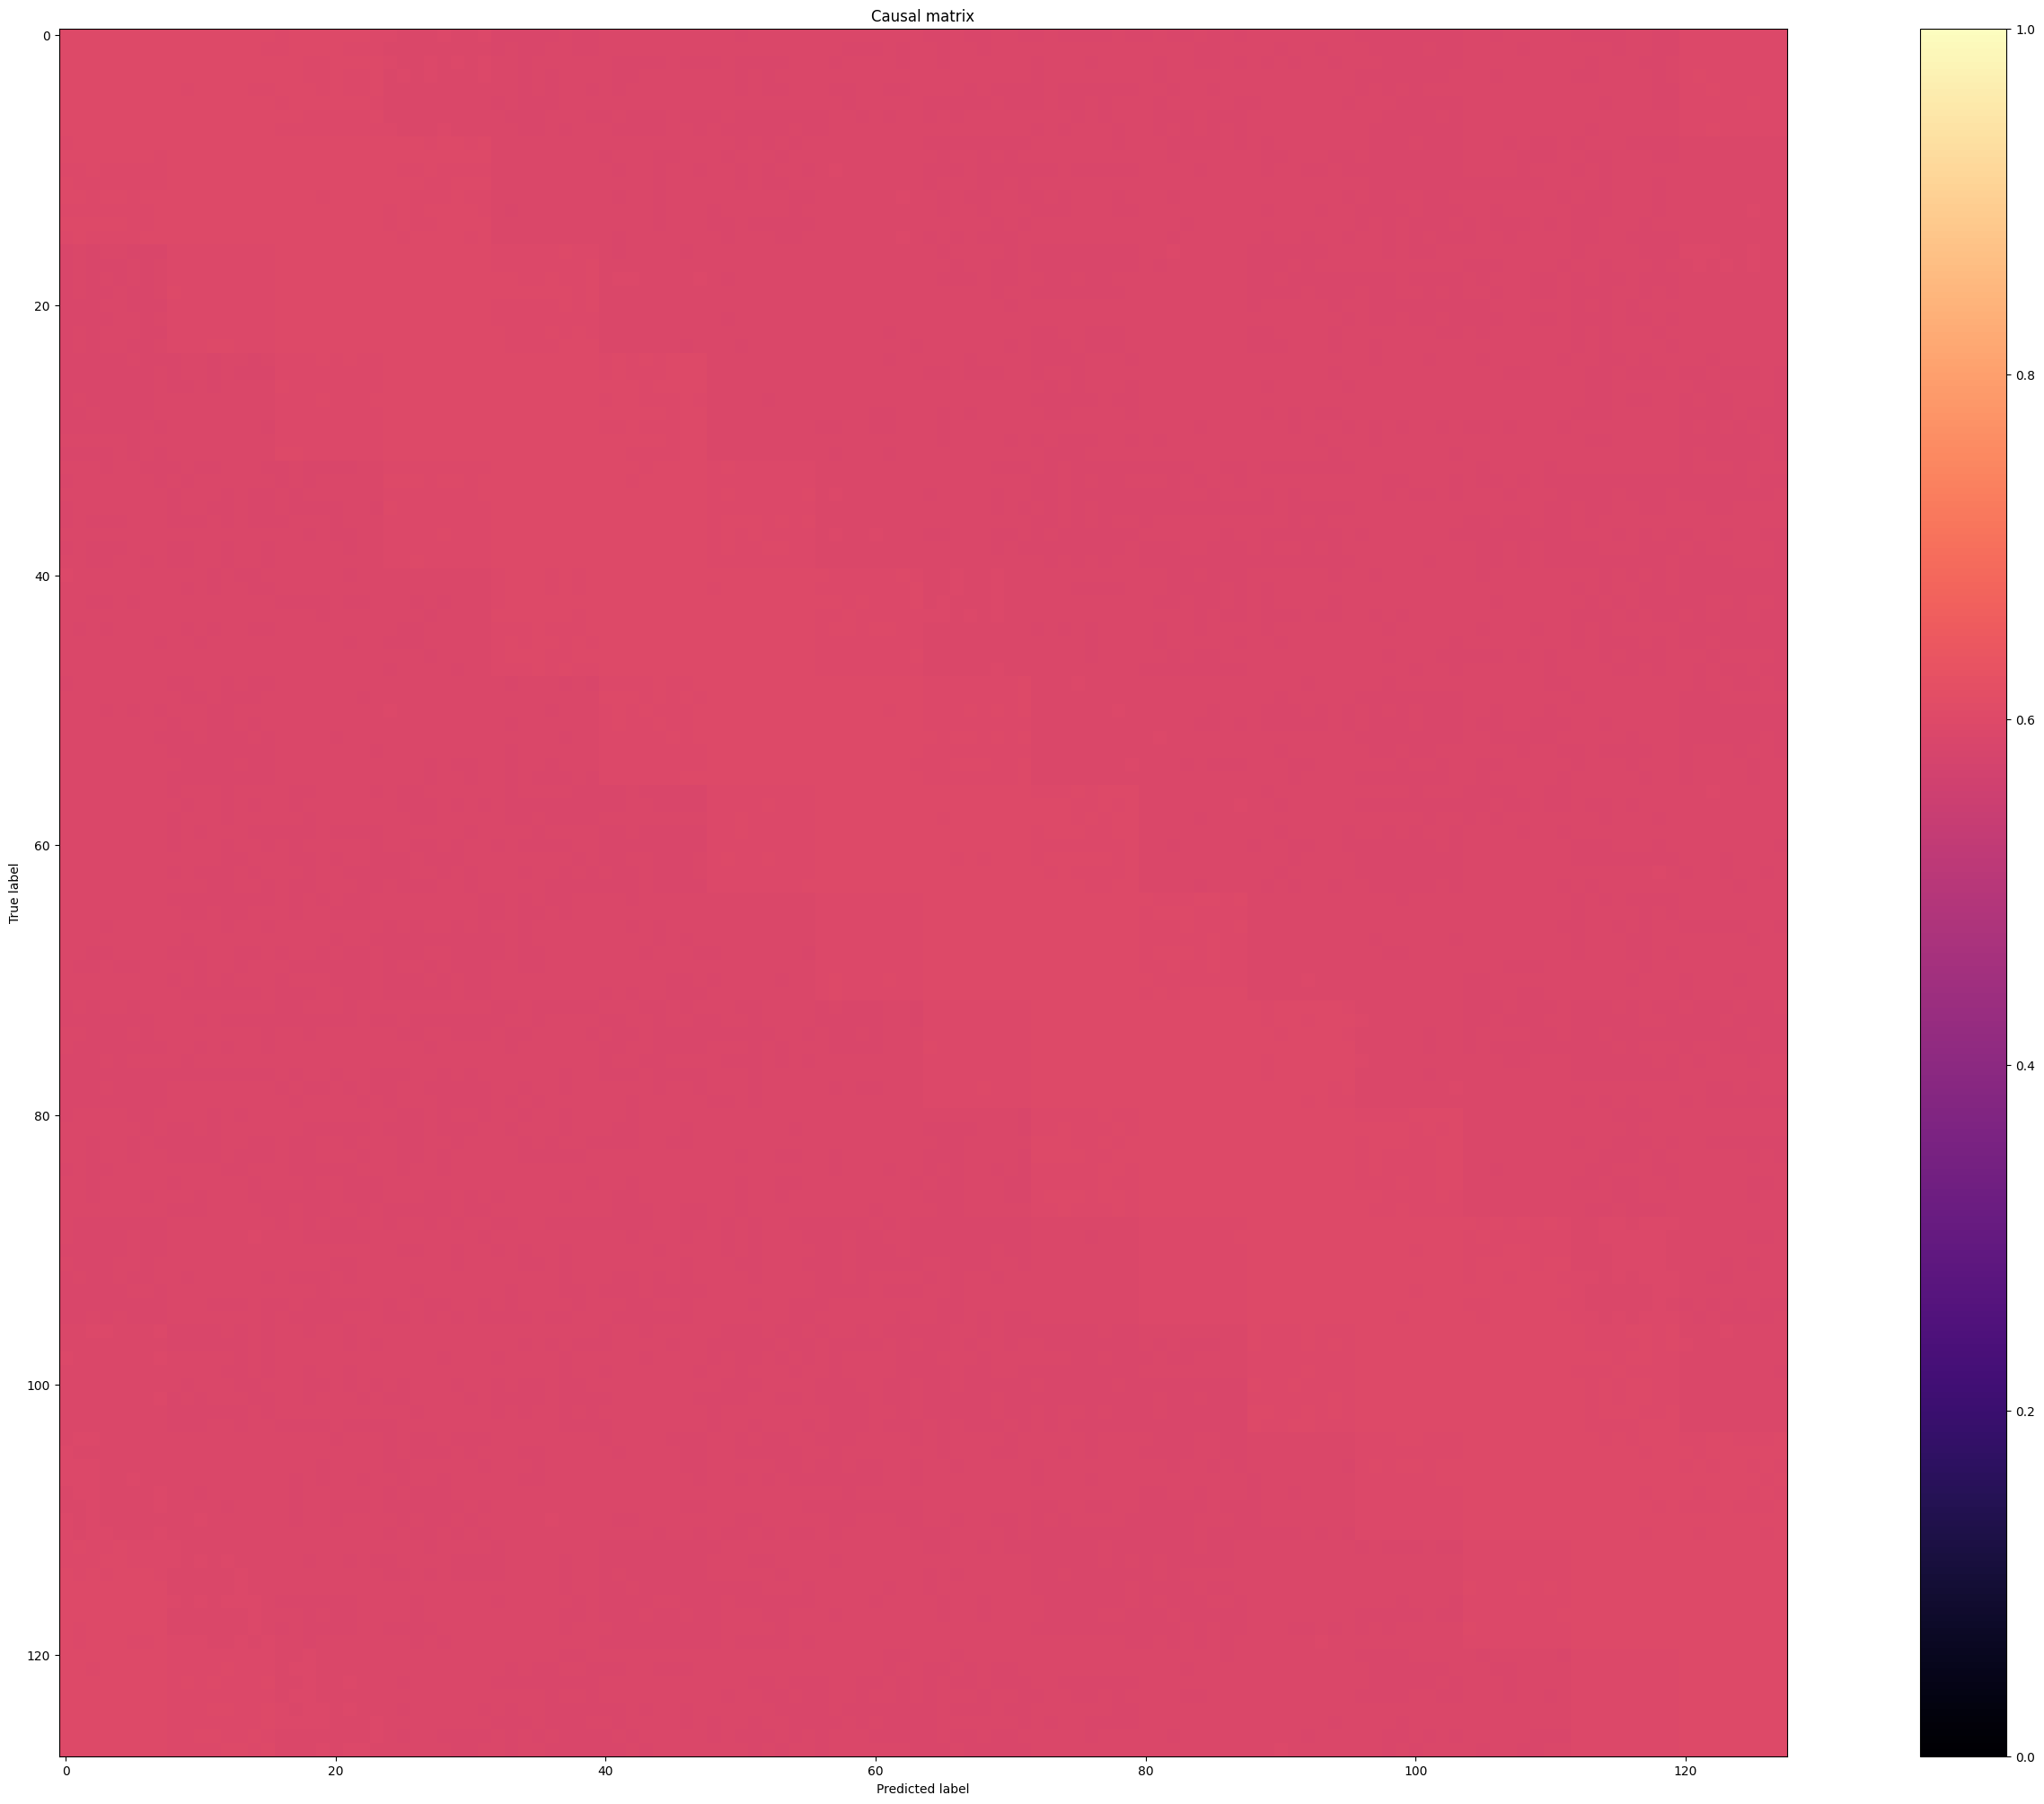

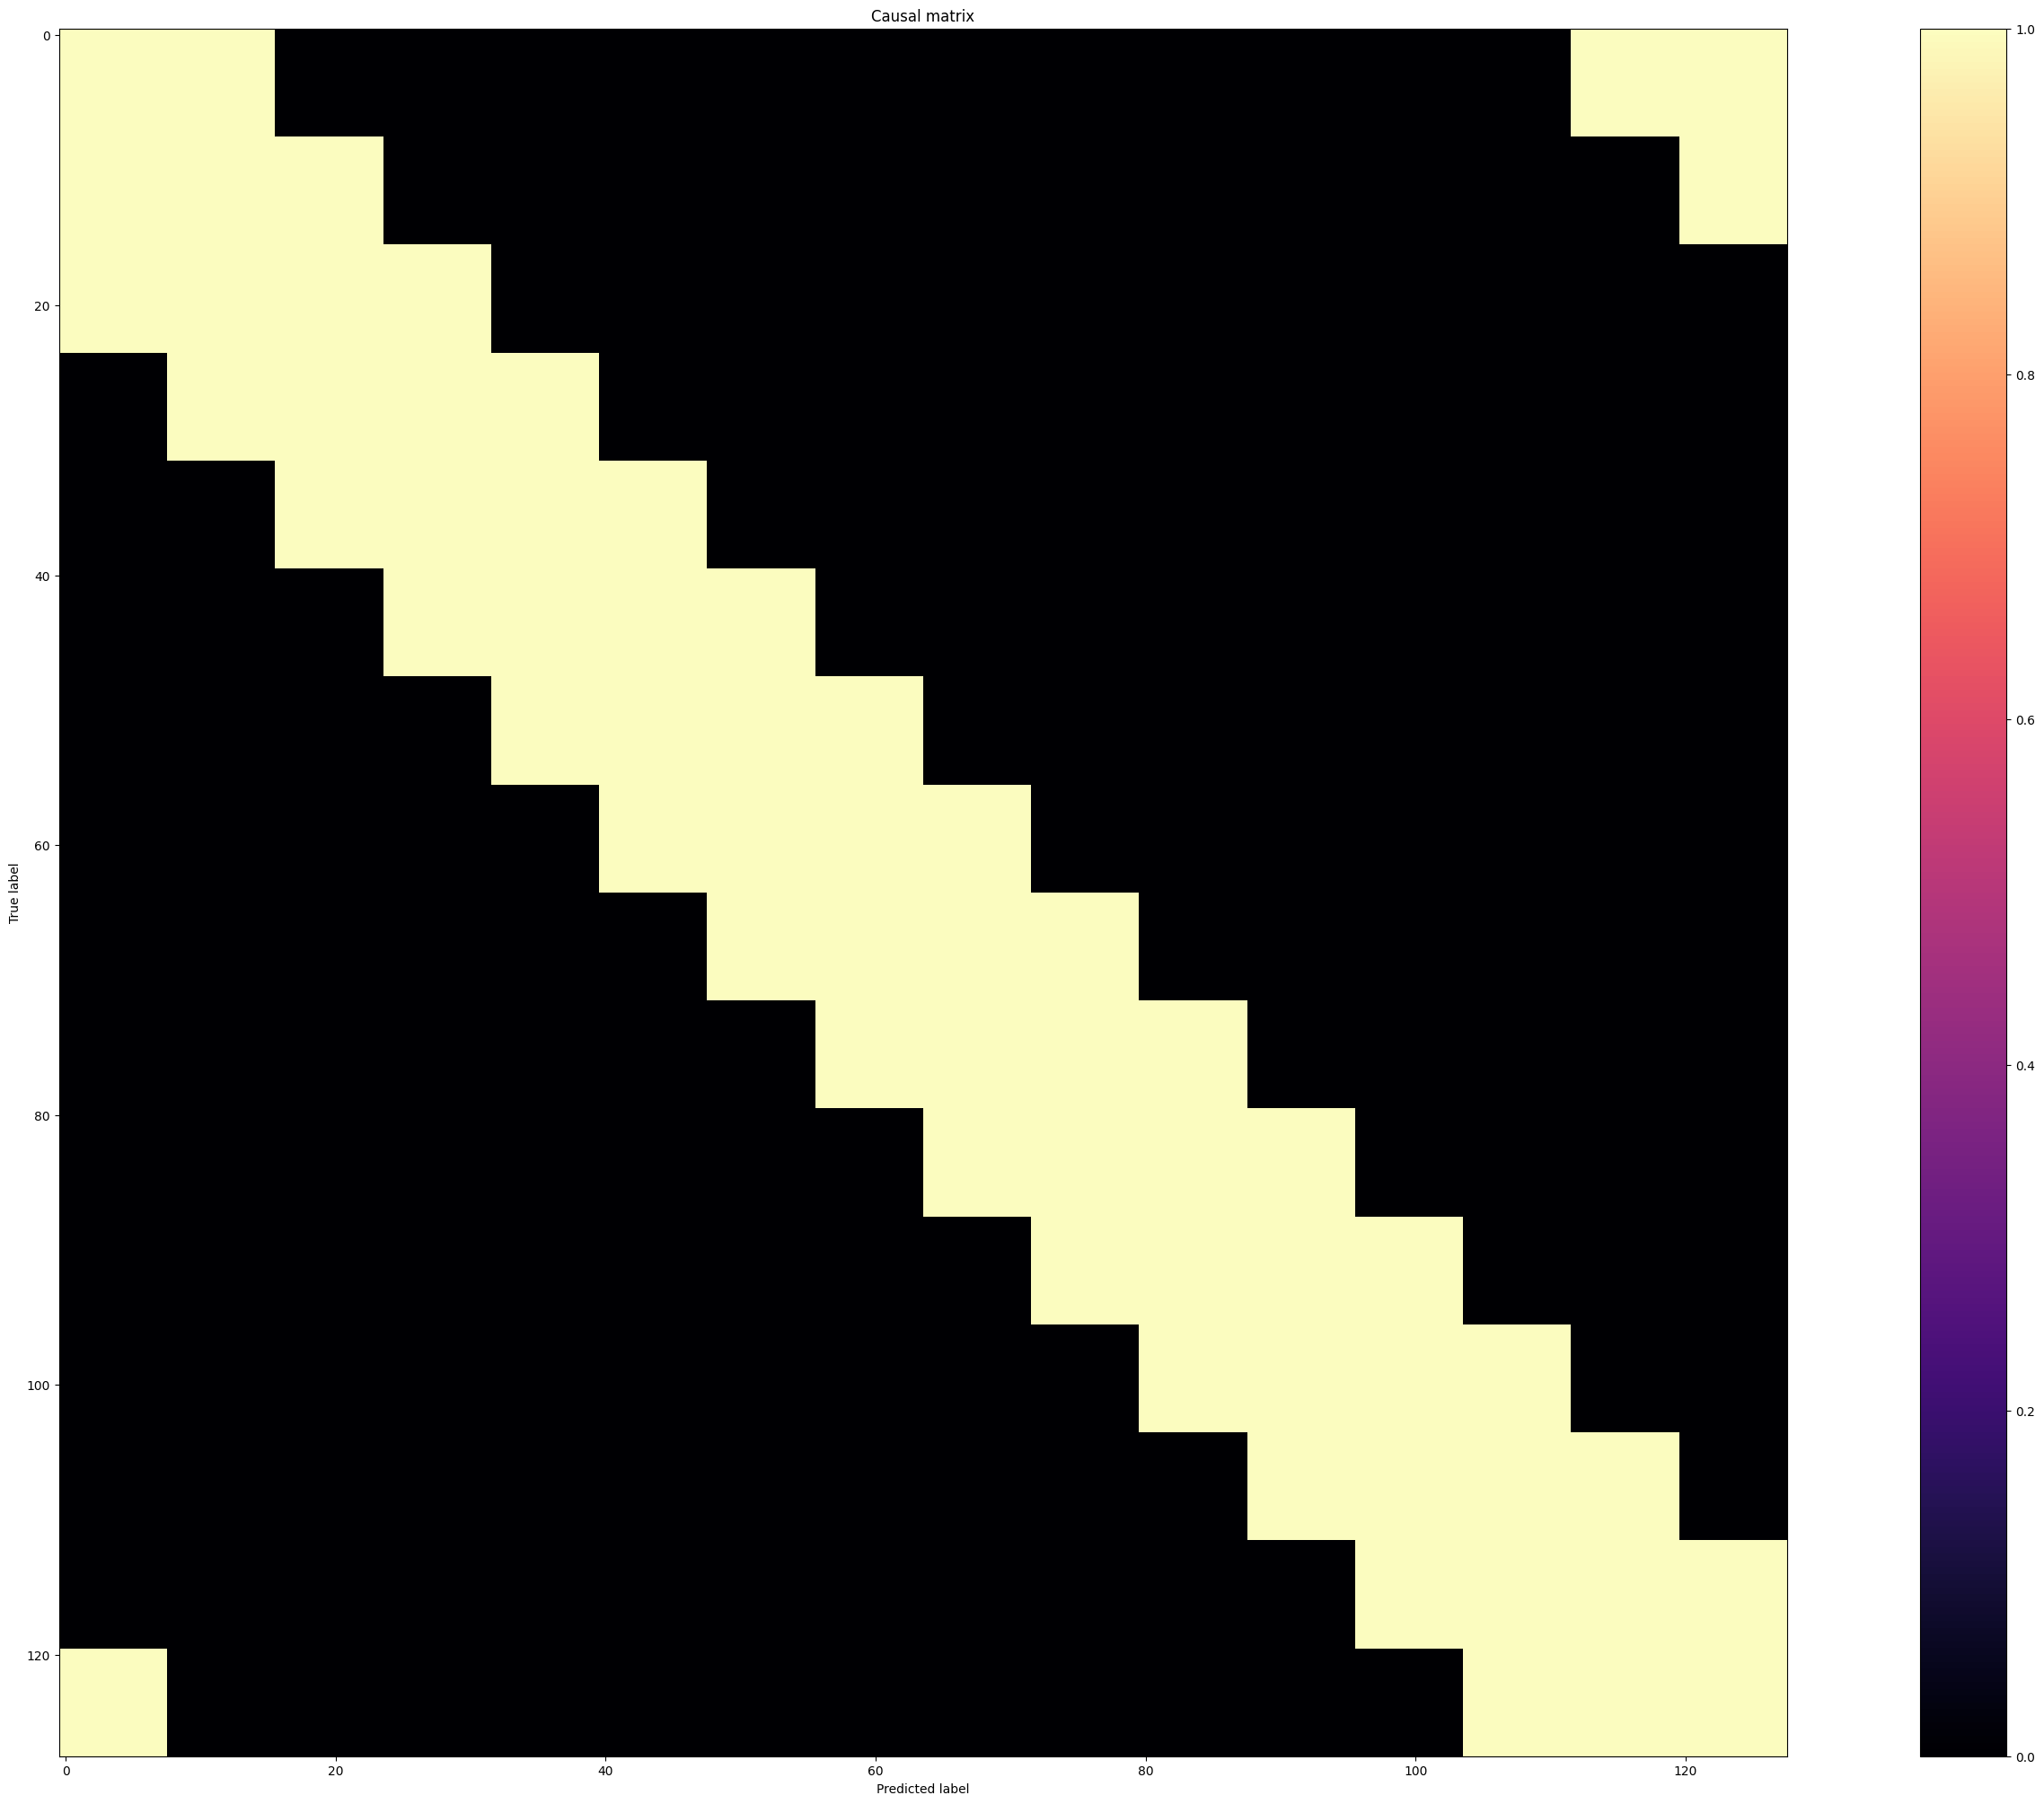

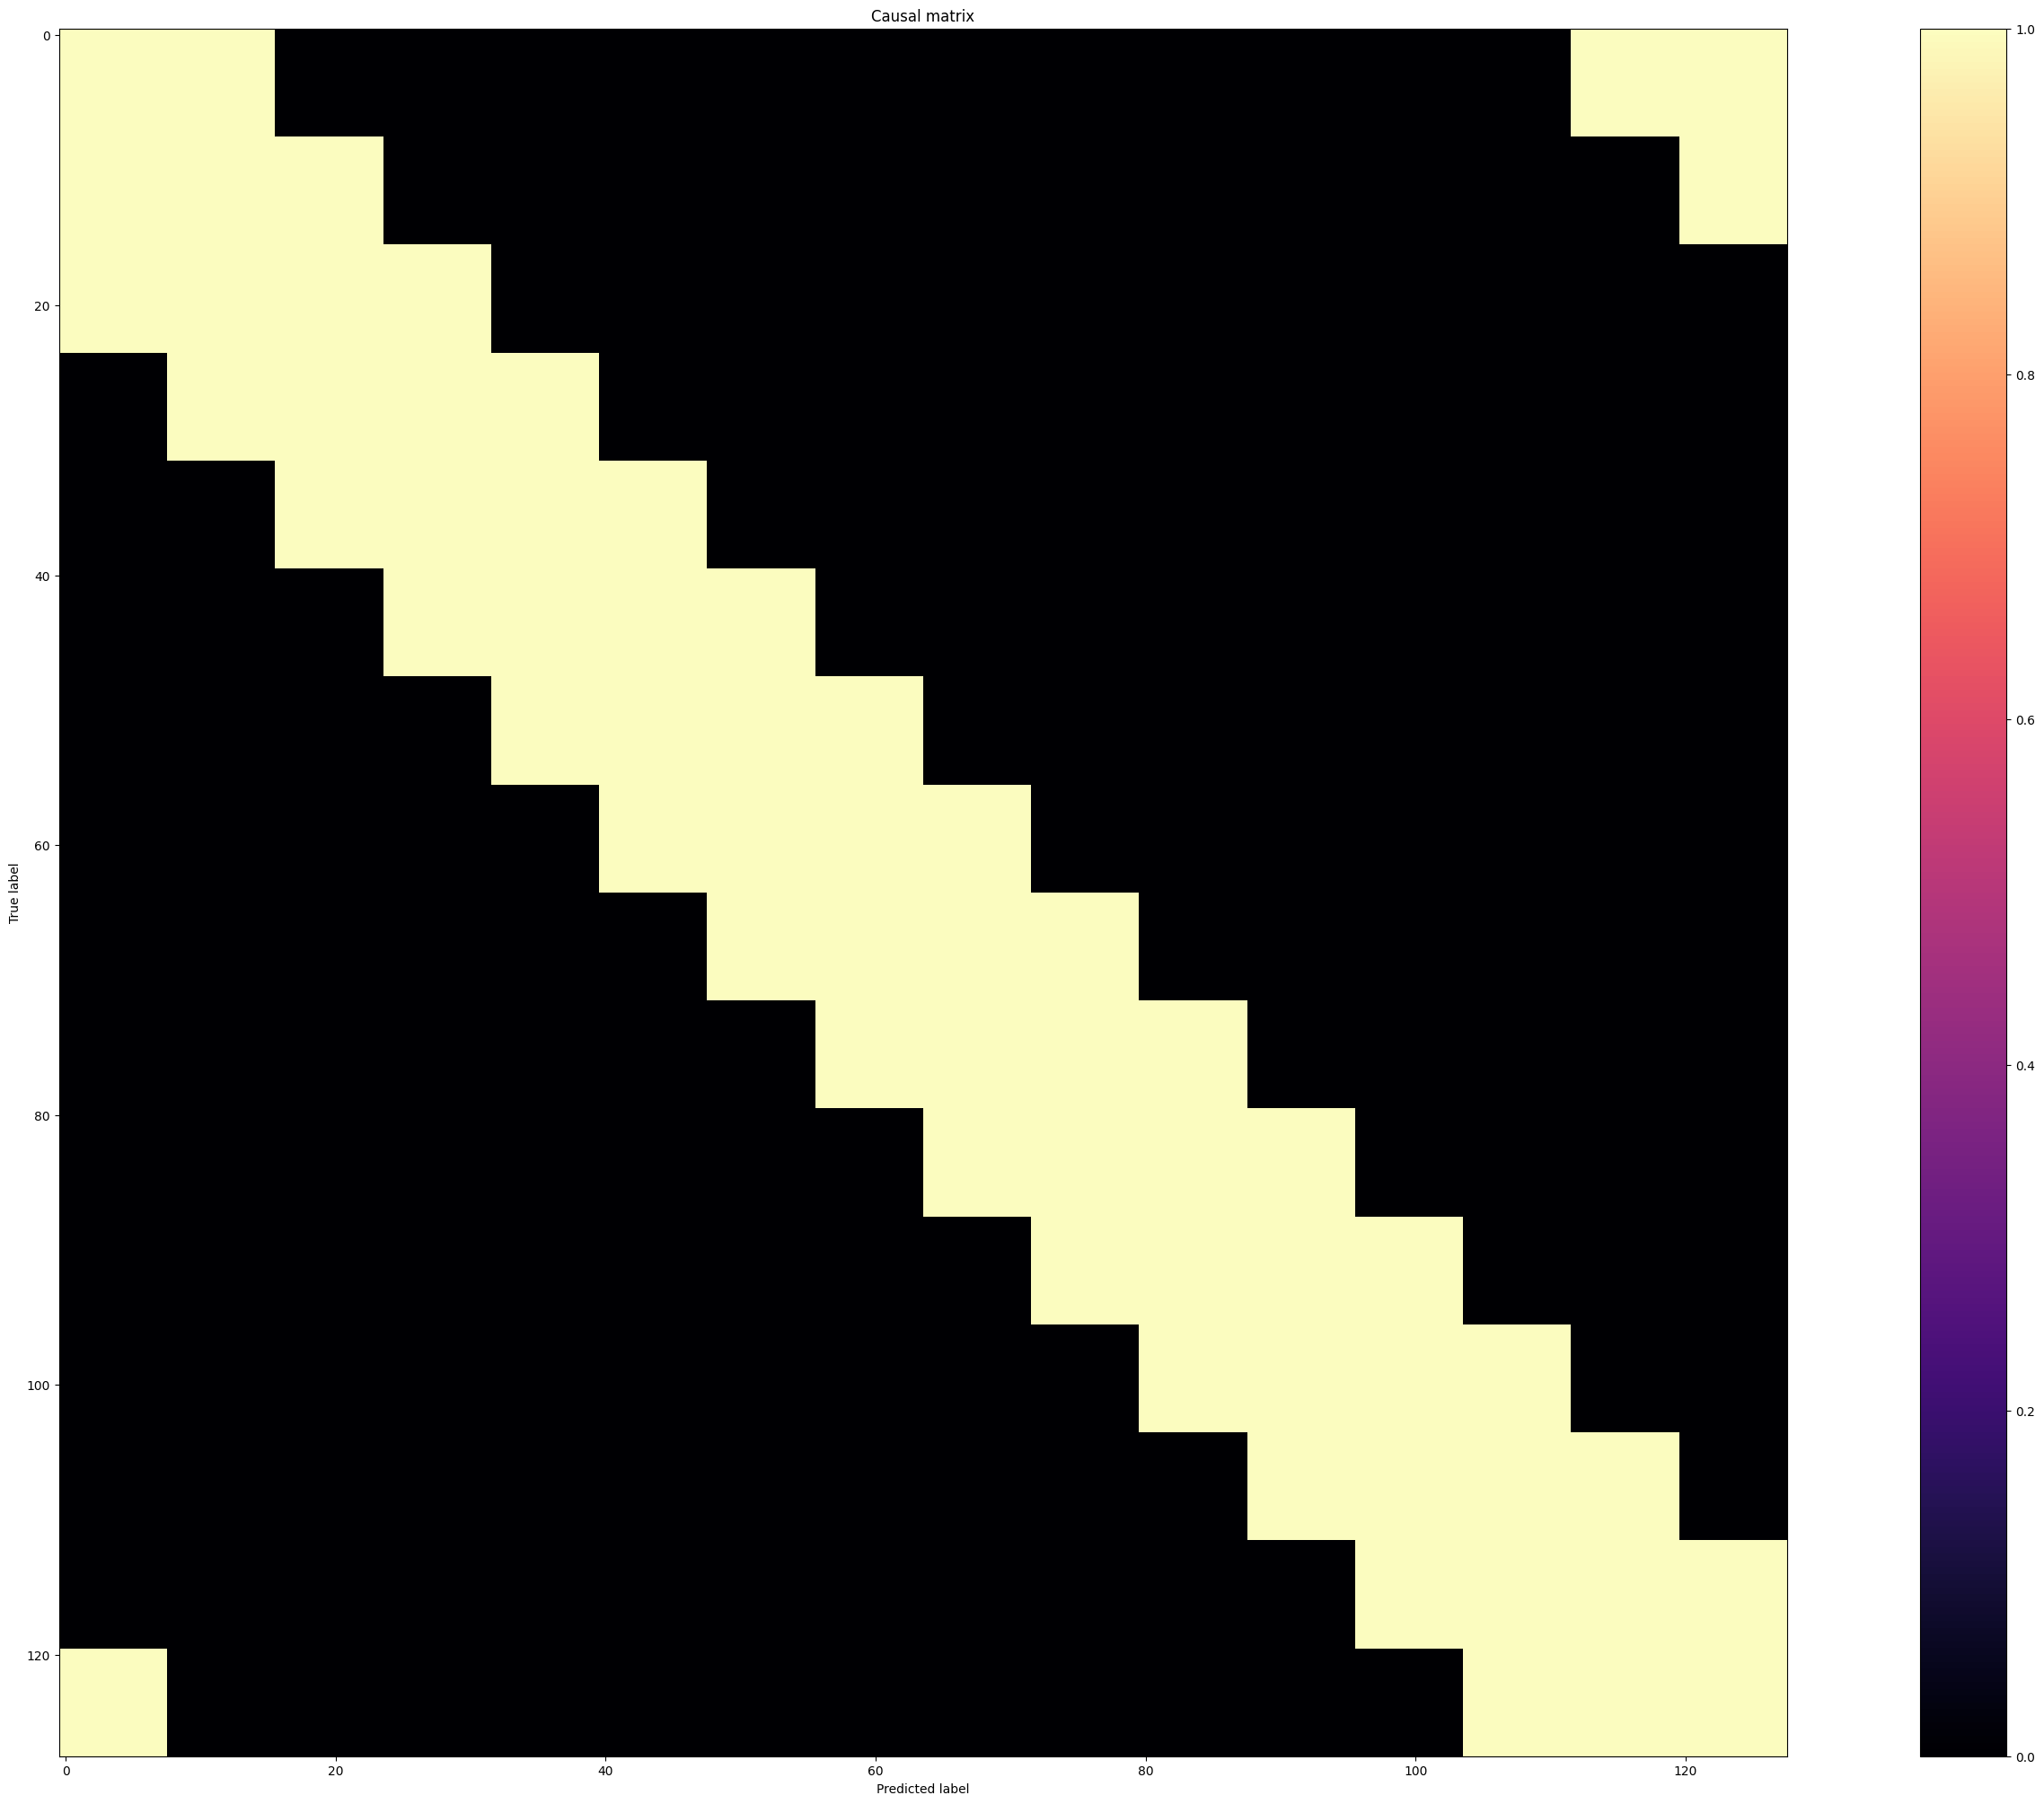

In [ ]:
# 读取导出的 Graph.npy 并做简单可视化
import numpy as np
import matplotlib.pyplot as plt

# lightning_module.on_fit_end 会将 Graph.npy 保存到 logger 目录
log_dir2 = None
if hasattr(logger2, 'log_dir') and logger2.log_dir is not None:
    log_dir2 = logger2.log_dir
else:
    log_dir2 = os.path.join(logger2.save_dir, logger2.name, f"version_{logger2.version}")

print(f"Reading Graph.npy from: {log_dir2}")
graph_path2 = os.path.join(log_dir2, 'Graph.npy')

if os.path.exists(graph_path2):
    Graph2 = np.load(graph_path2)
    print("Graph shape:", Graph2.shape)
    graph2 = (Graph2 - np.min(Graph2)) / (np.max(Graph2) - np.min(Graph2))

    plt.figure(figsize=(6, 5))
    plt.imshow(graph2, cmap='magma', vmin=0, vmax=1)
    plt.title('Final Causal Graph (prob) (patches)')
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("Graph.npy not found for patches experiment. Check that training finished and saving succeeded.")

# true_cm 可视化
from utils.misc import plot_causal_matrix

true_cm2 = datamodule2.true_cm
if true_cm2 is not None:
    n = true_cm2.shape[0]
    figsize = [1.5 * n, 1.0 * n]
    fig_true2 = plot_causal_matrix(true_cm2, figsize=figsize, show_text=False, vmin=0, vmax=1)
    display(fig_true2)
else:
    print("true_cm is None for patches experiment.")

